Fitting Growing Neural Gas Network for mnist_one_00080.png...


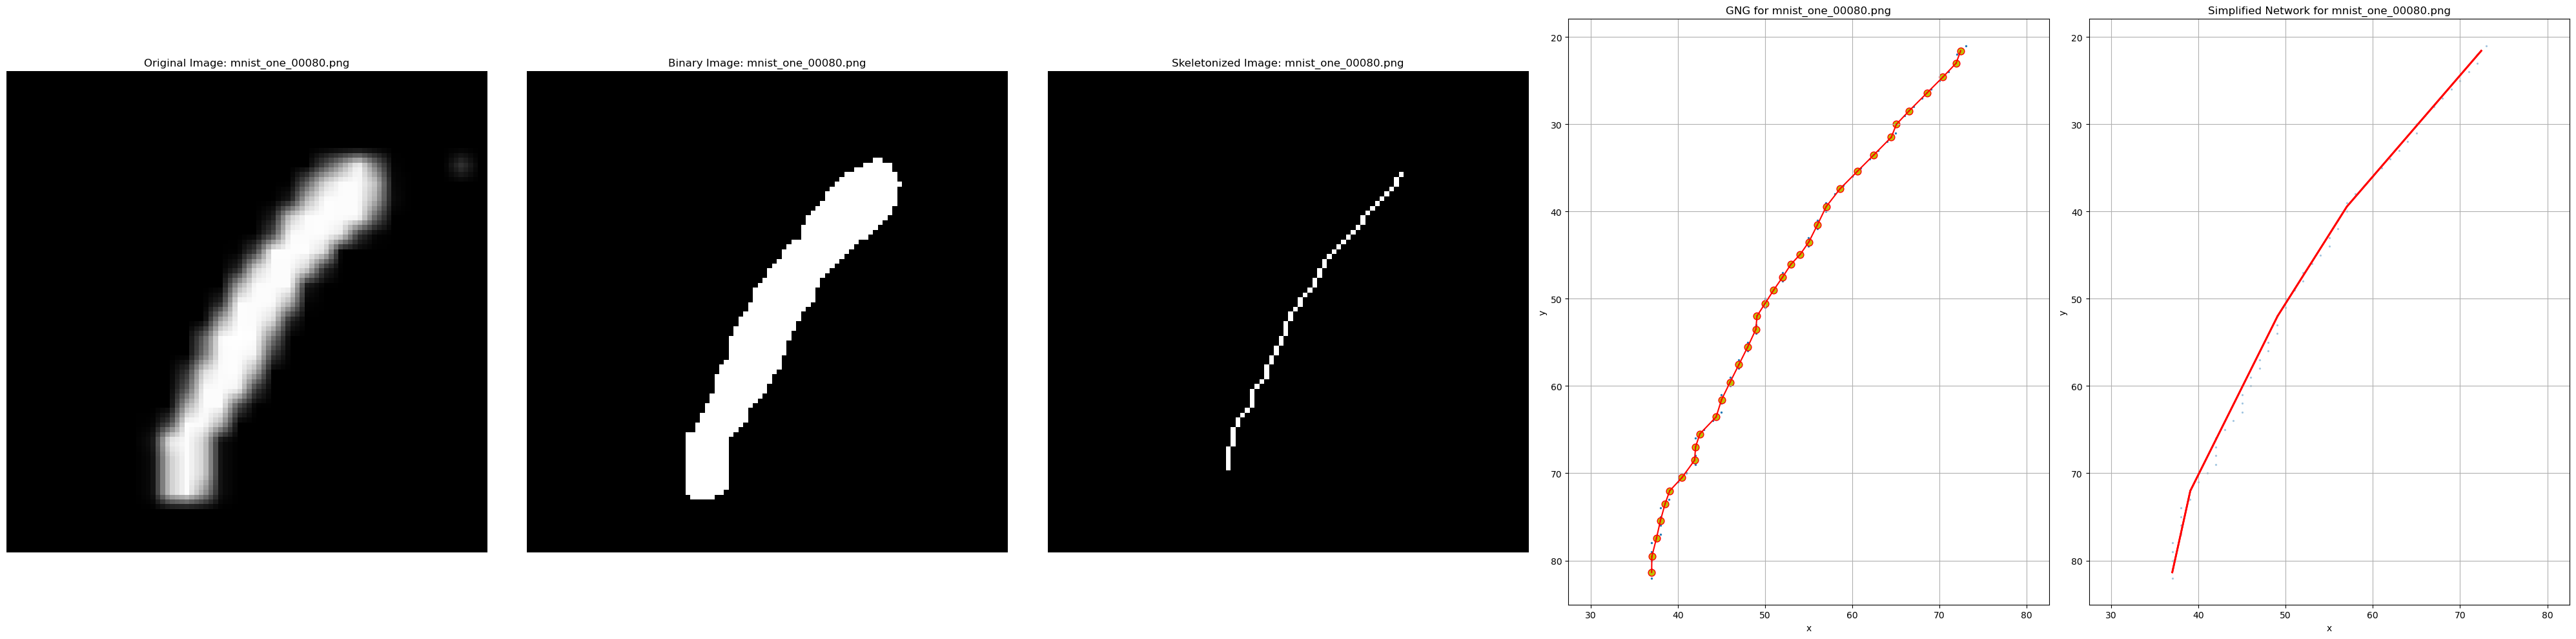

Fitting Growing Neural Gas Network for mnist_one_00094.png...


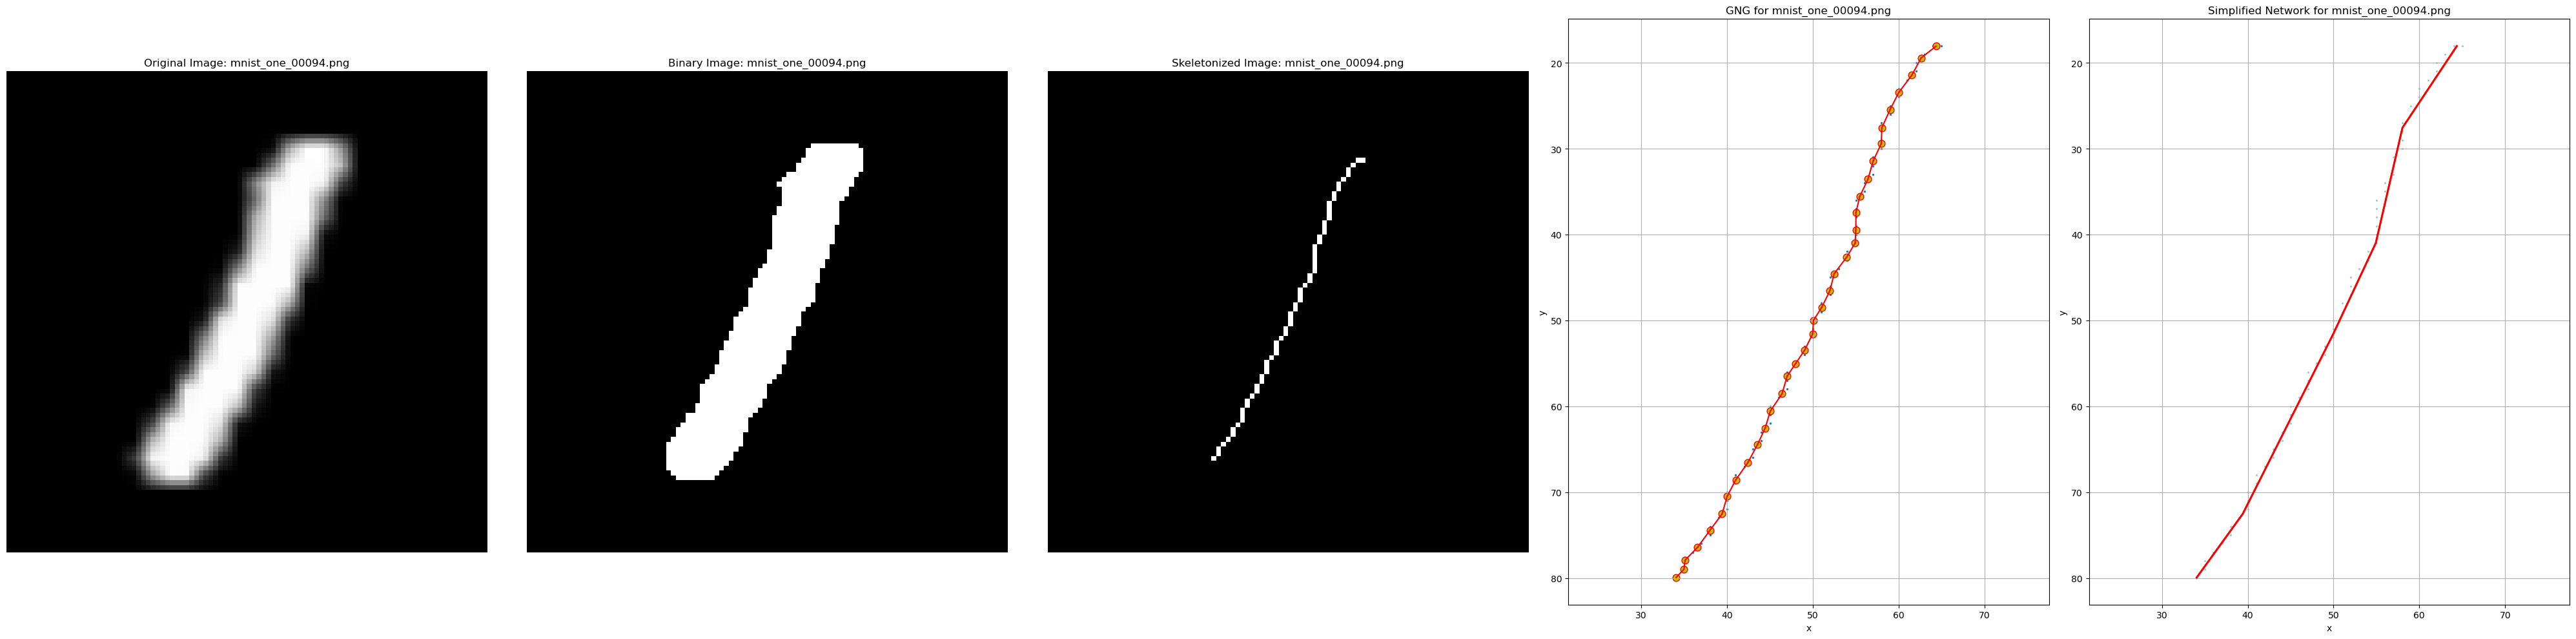

Fitting Growing Neural Gas Network for mnist_one_00043.png...


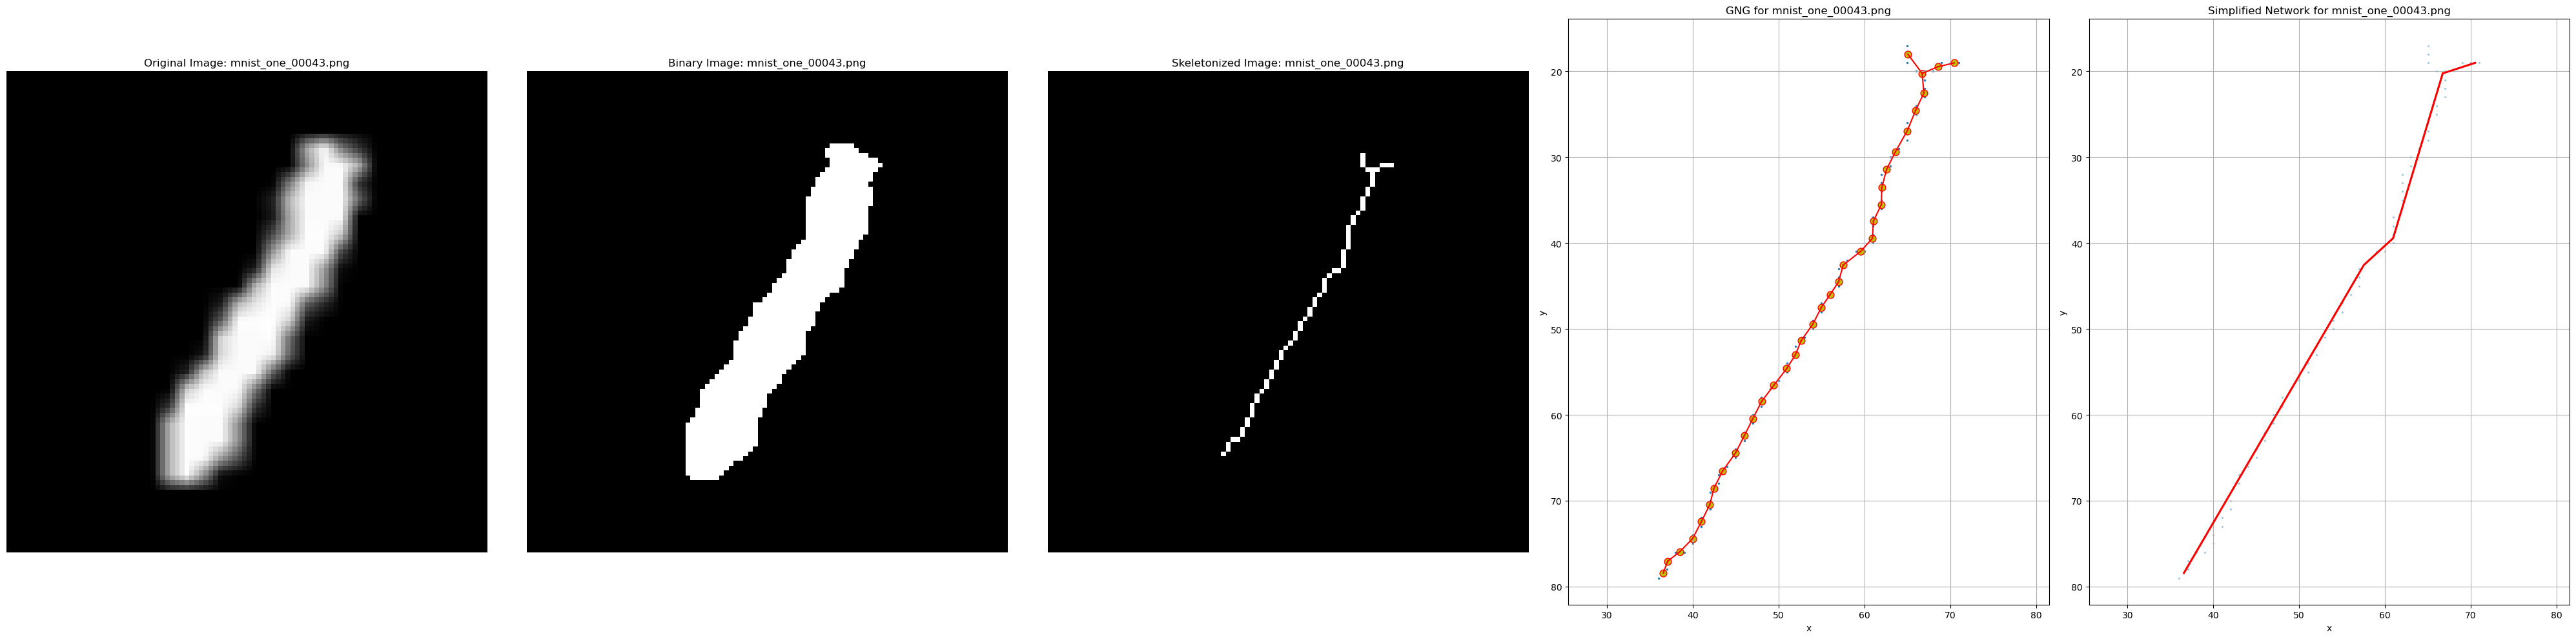

Fitting Growing Neural Gas Network for mnist_one_00057.png...


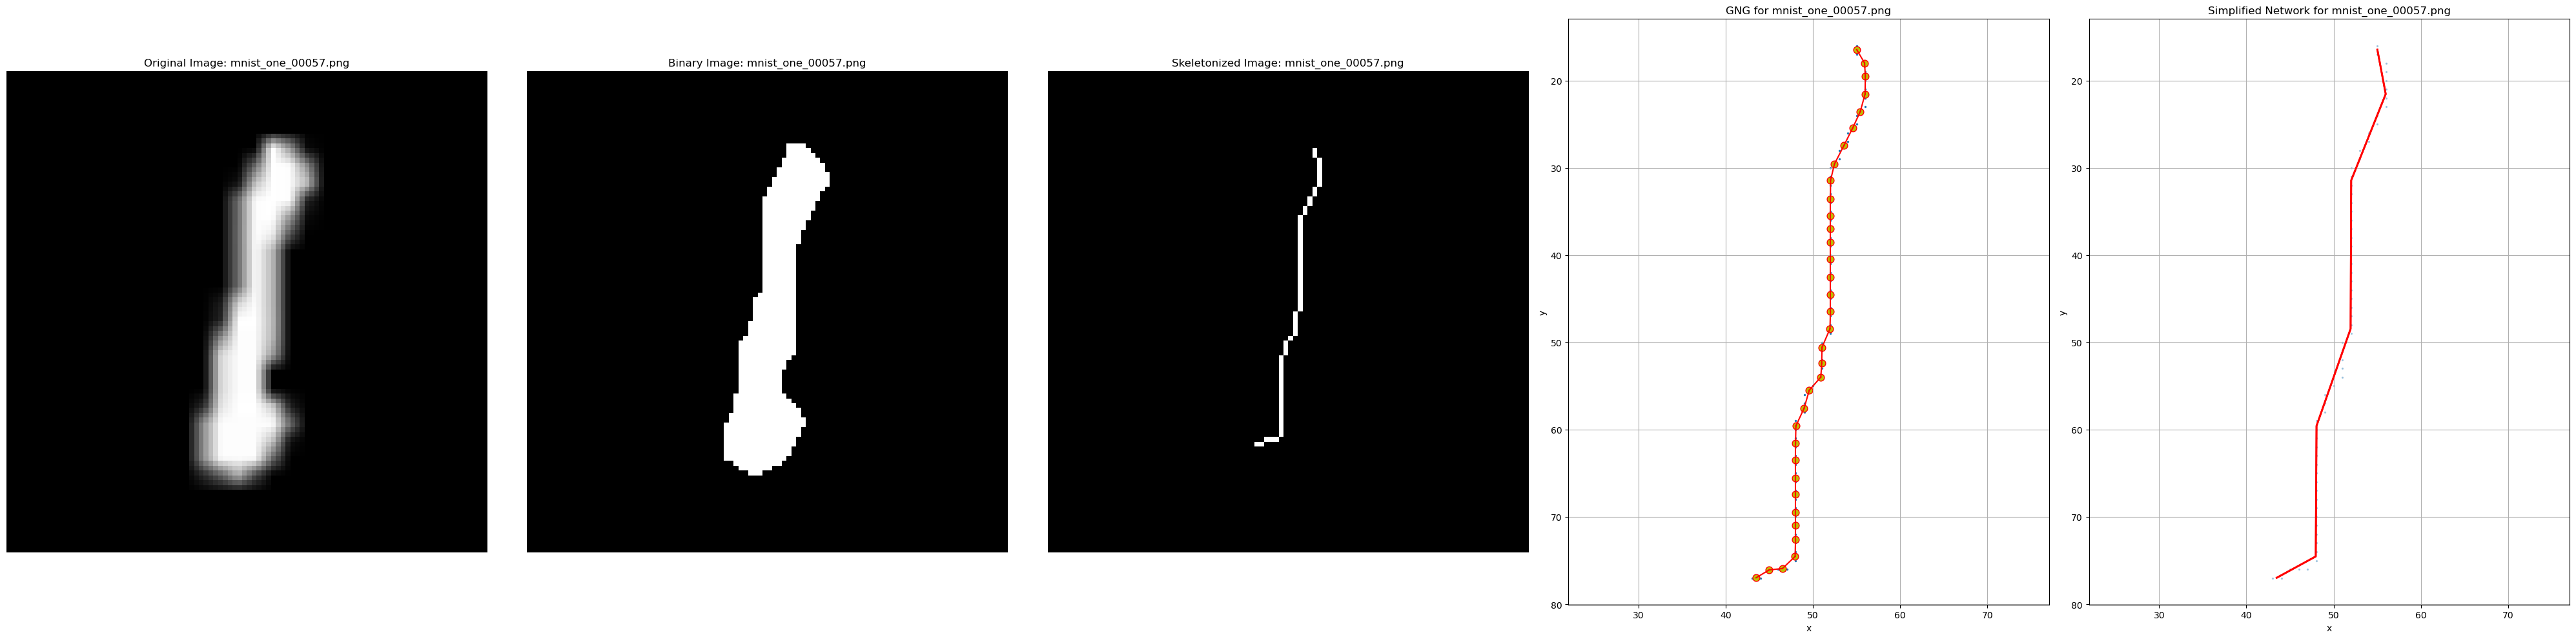

Fitting Growing Neural Gas Network for mnist_one_00056.png...


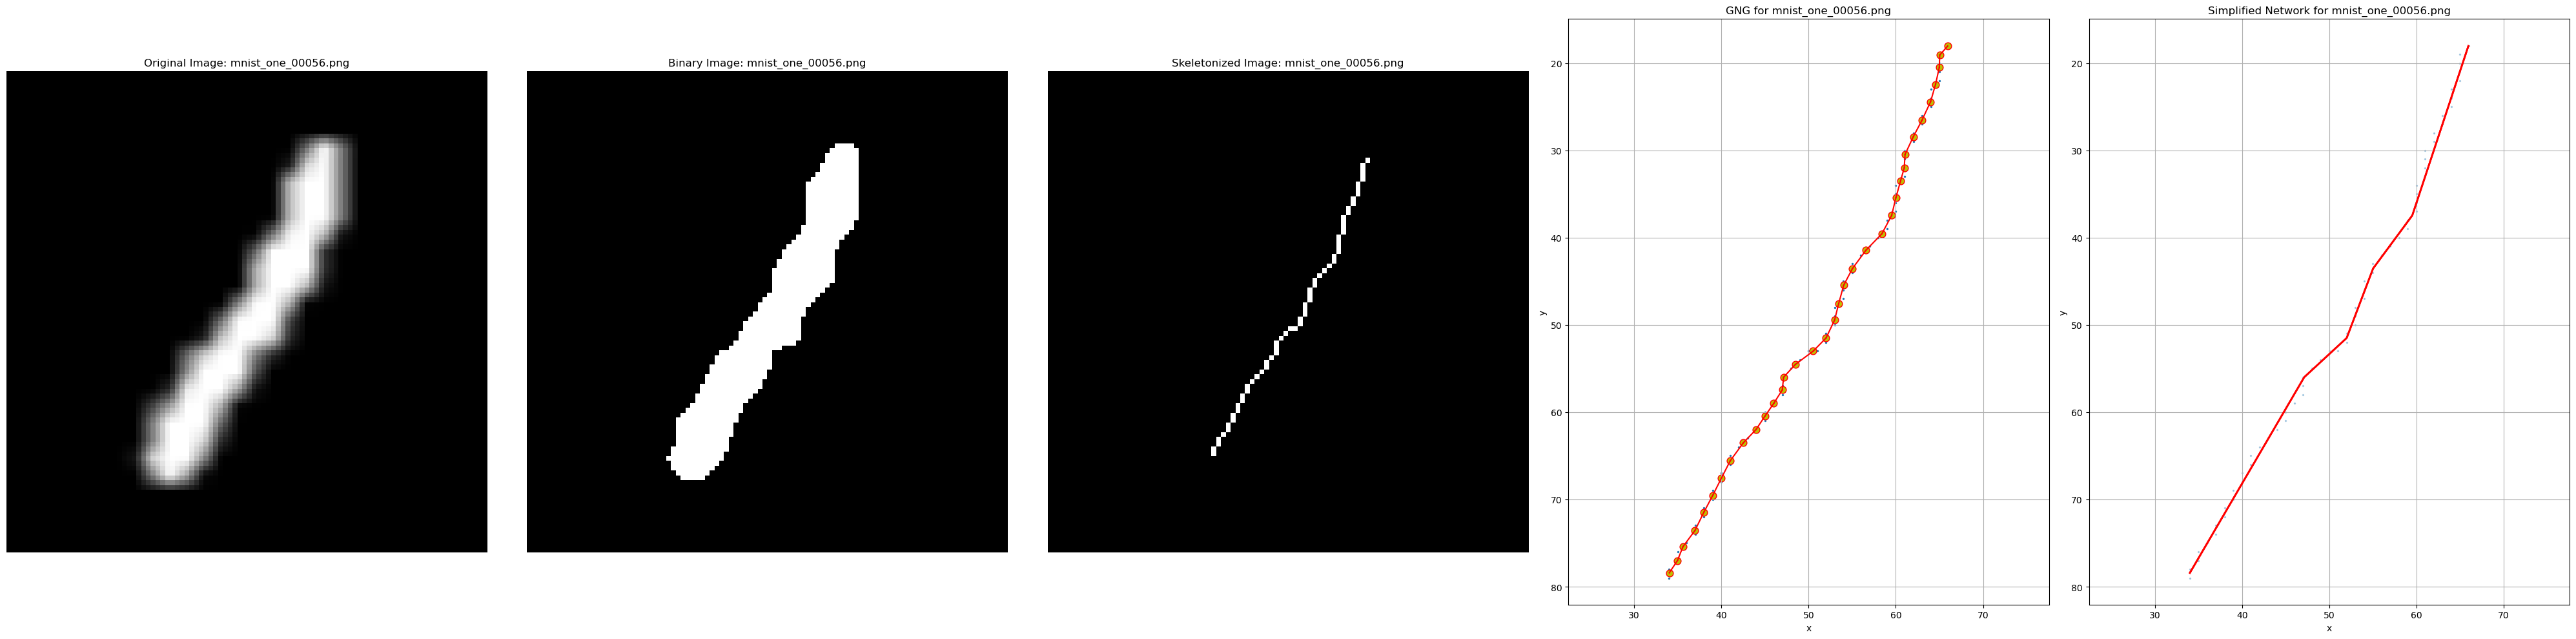

Fitting Growing Neural Gas Network for mnist_one_00042.png...


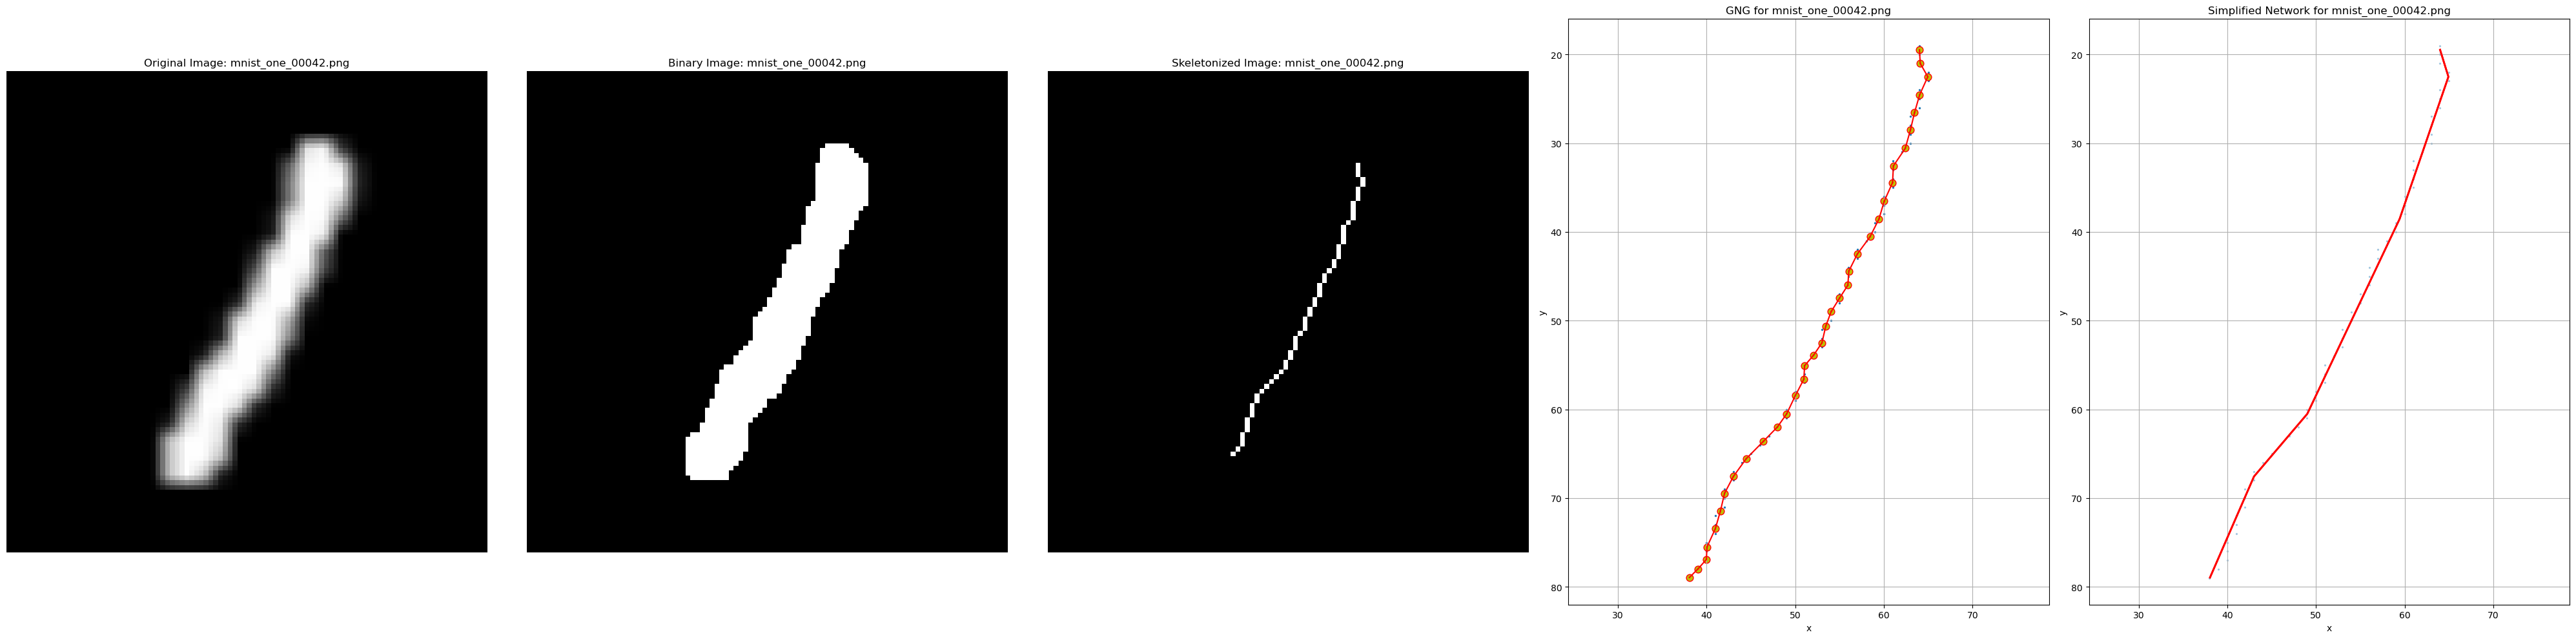

Fitting Growing Neural Gas Network for mnist_one_00095.png...


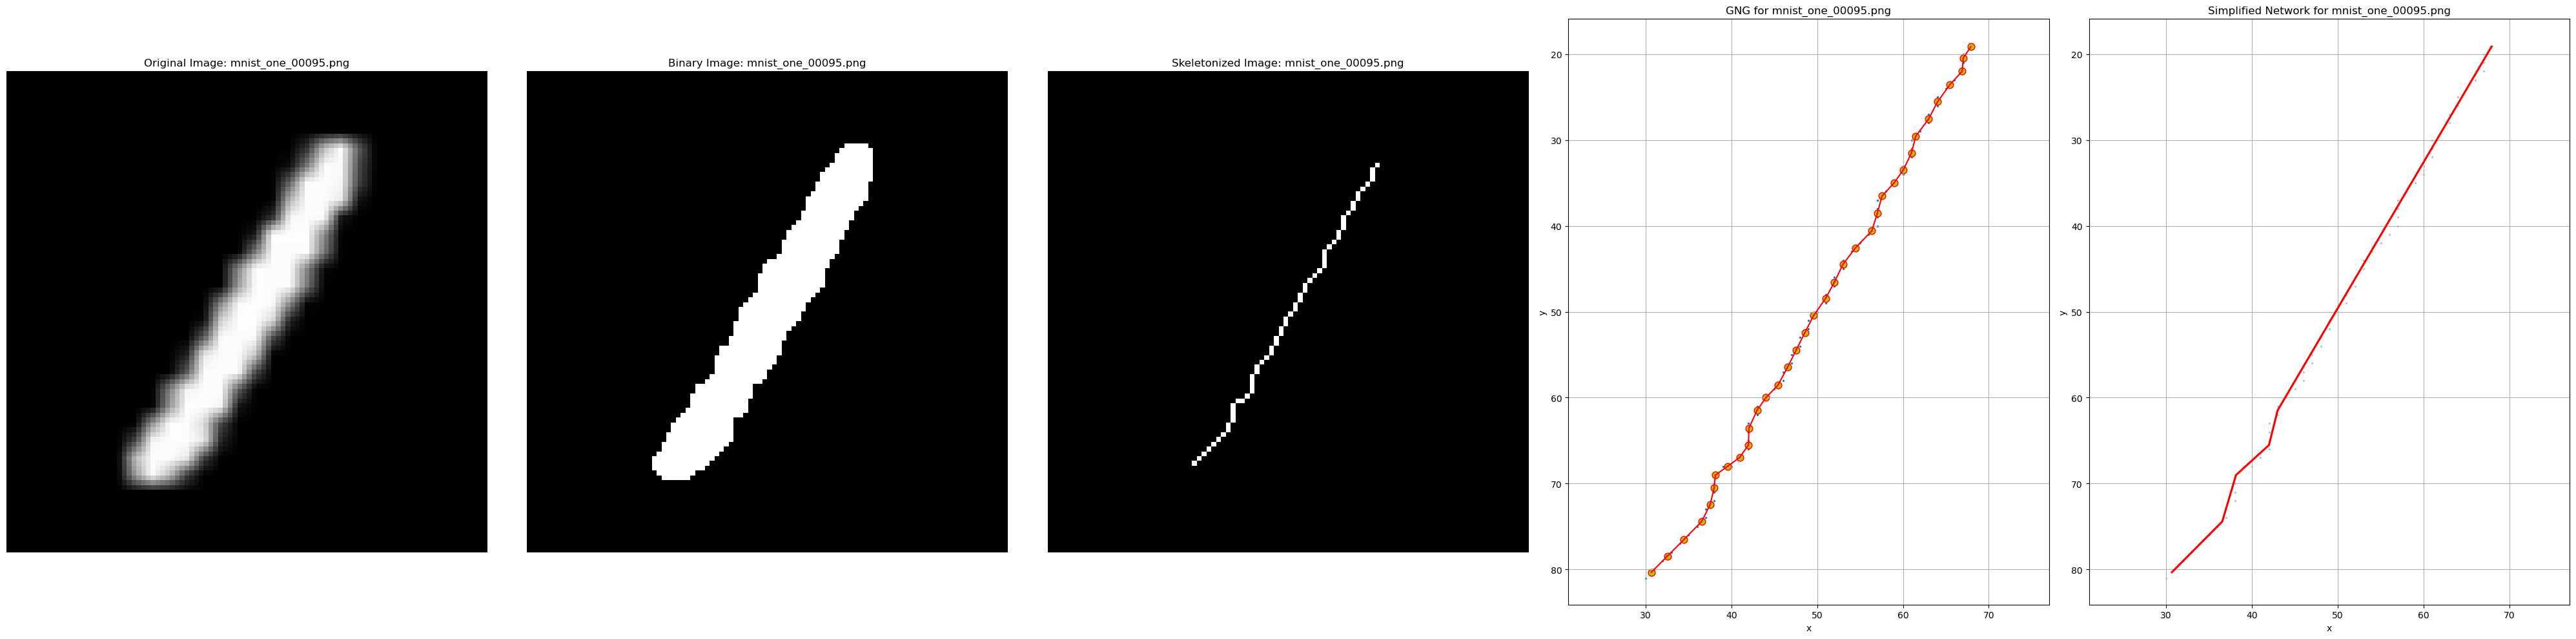

Fitting Growing Neural Gas Network for mnist_one_00081.png...


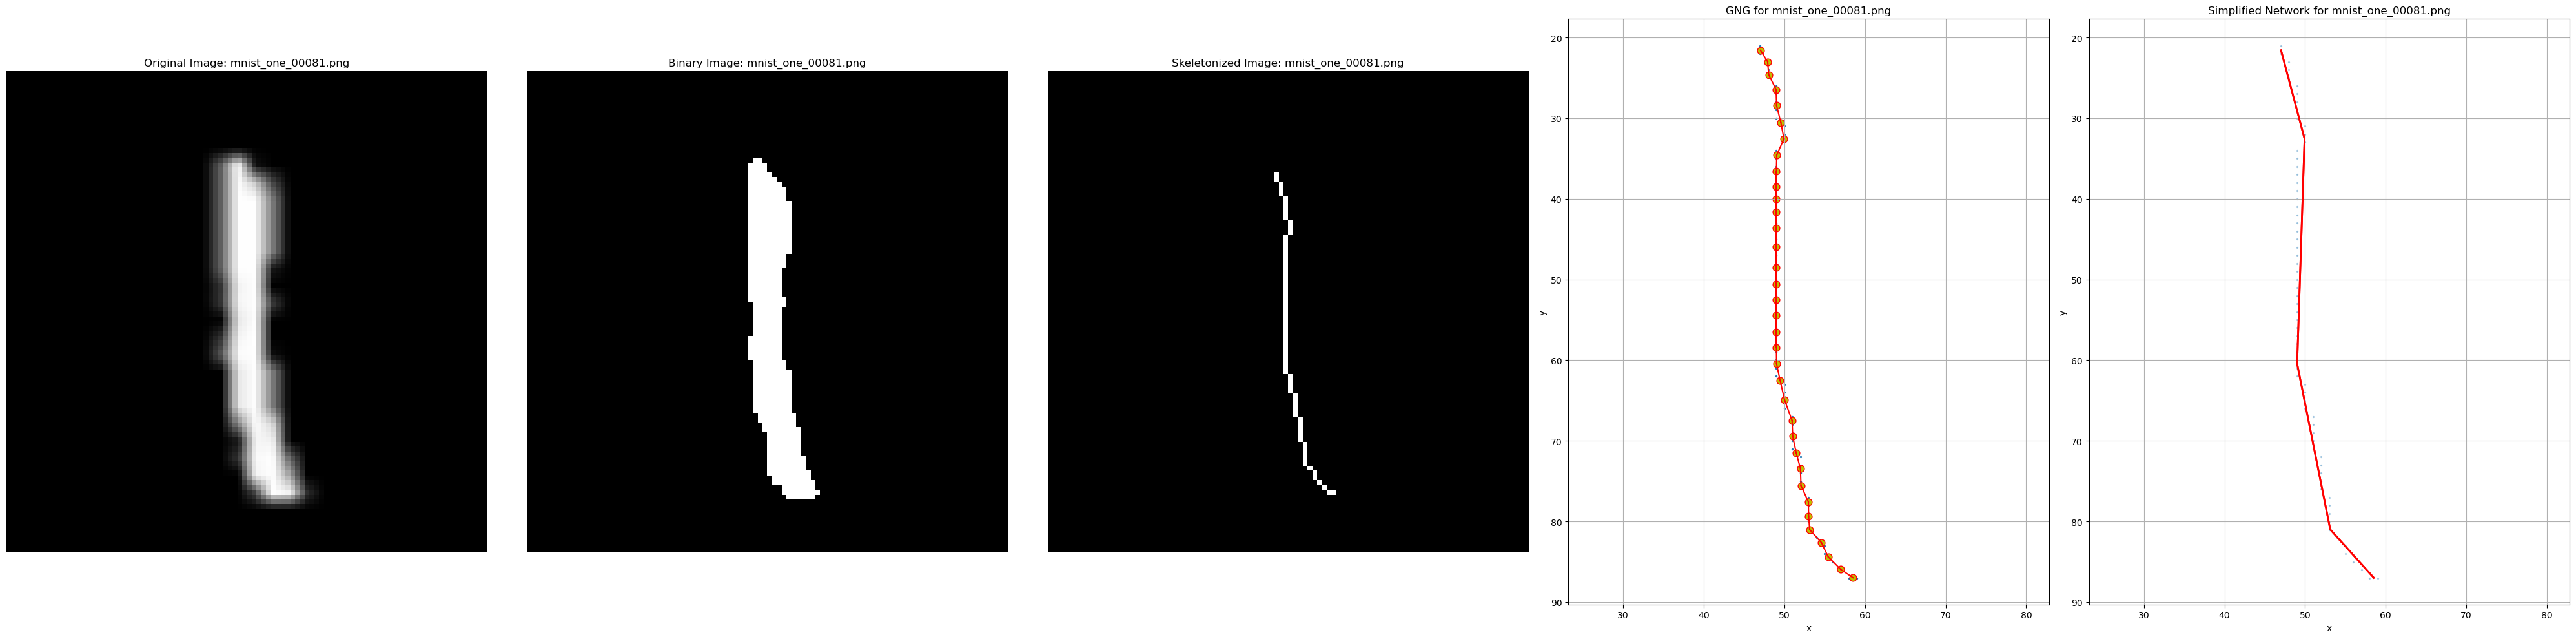

Fitting Growing Neural Gas Network for mnist_one_00097.png...


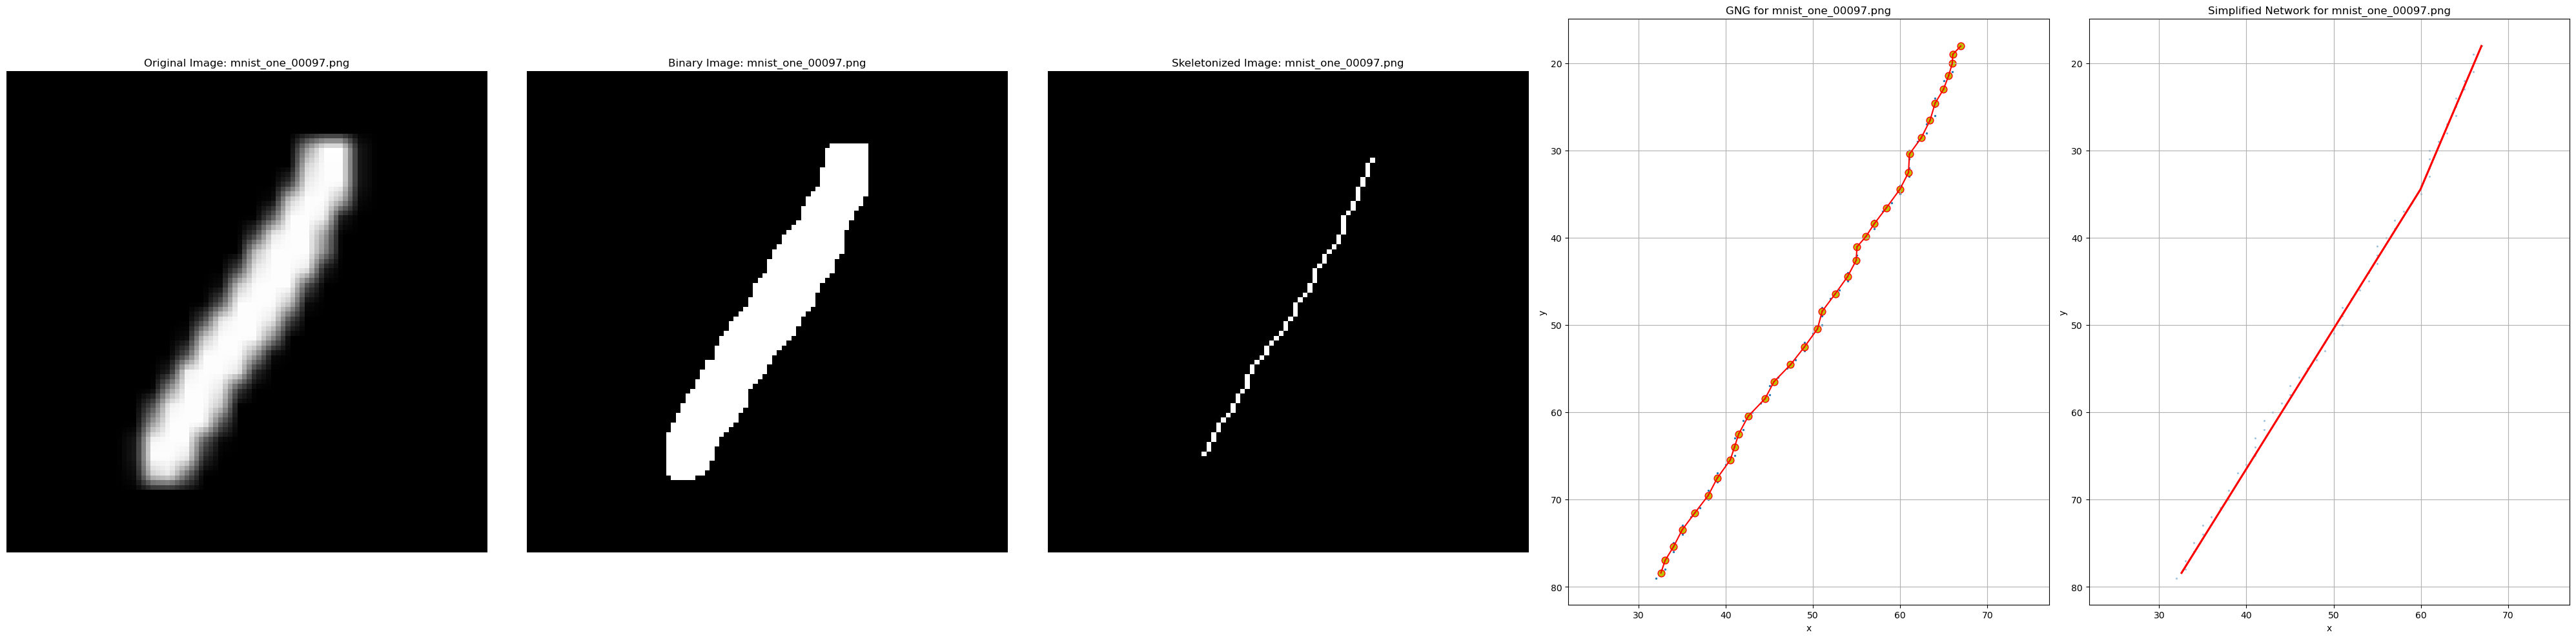

Fitting Growing Neural Gas Network for mnist_one_00083.png...


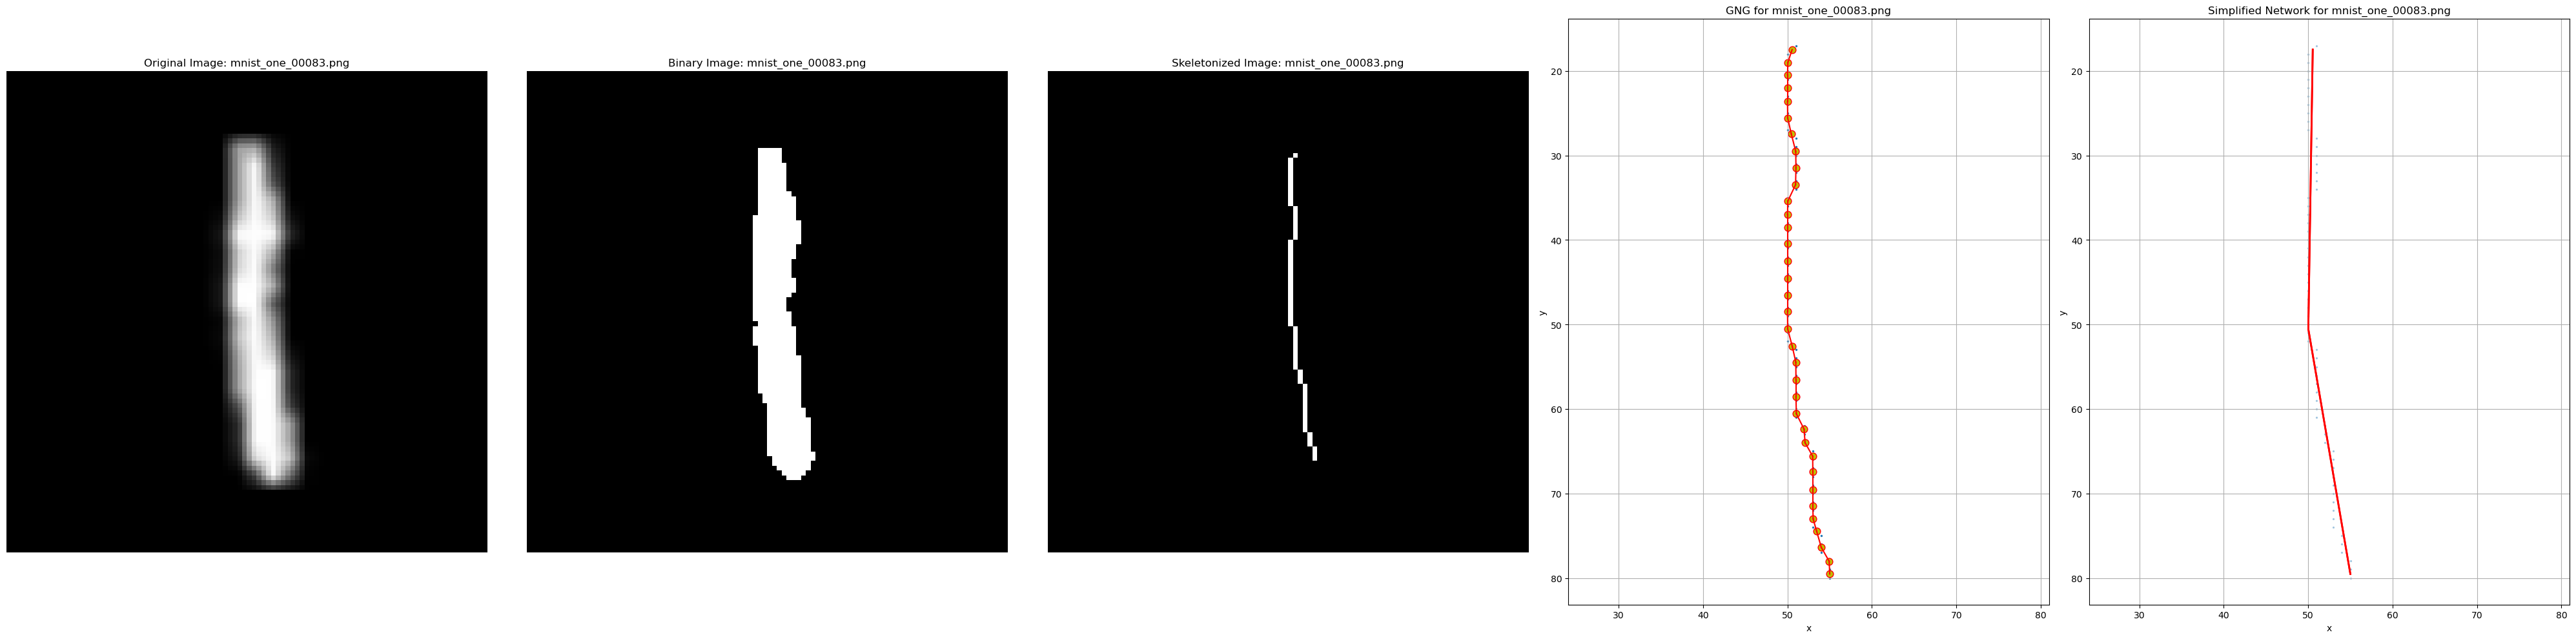

Fitting Growing Neural Gas Network for mnist_one_00068.png...


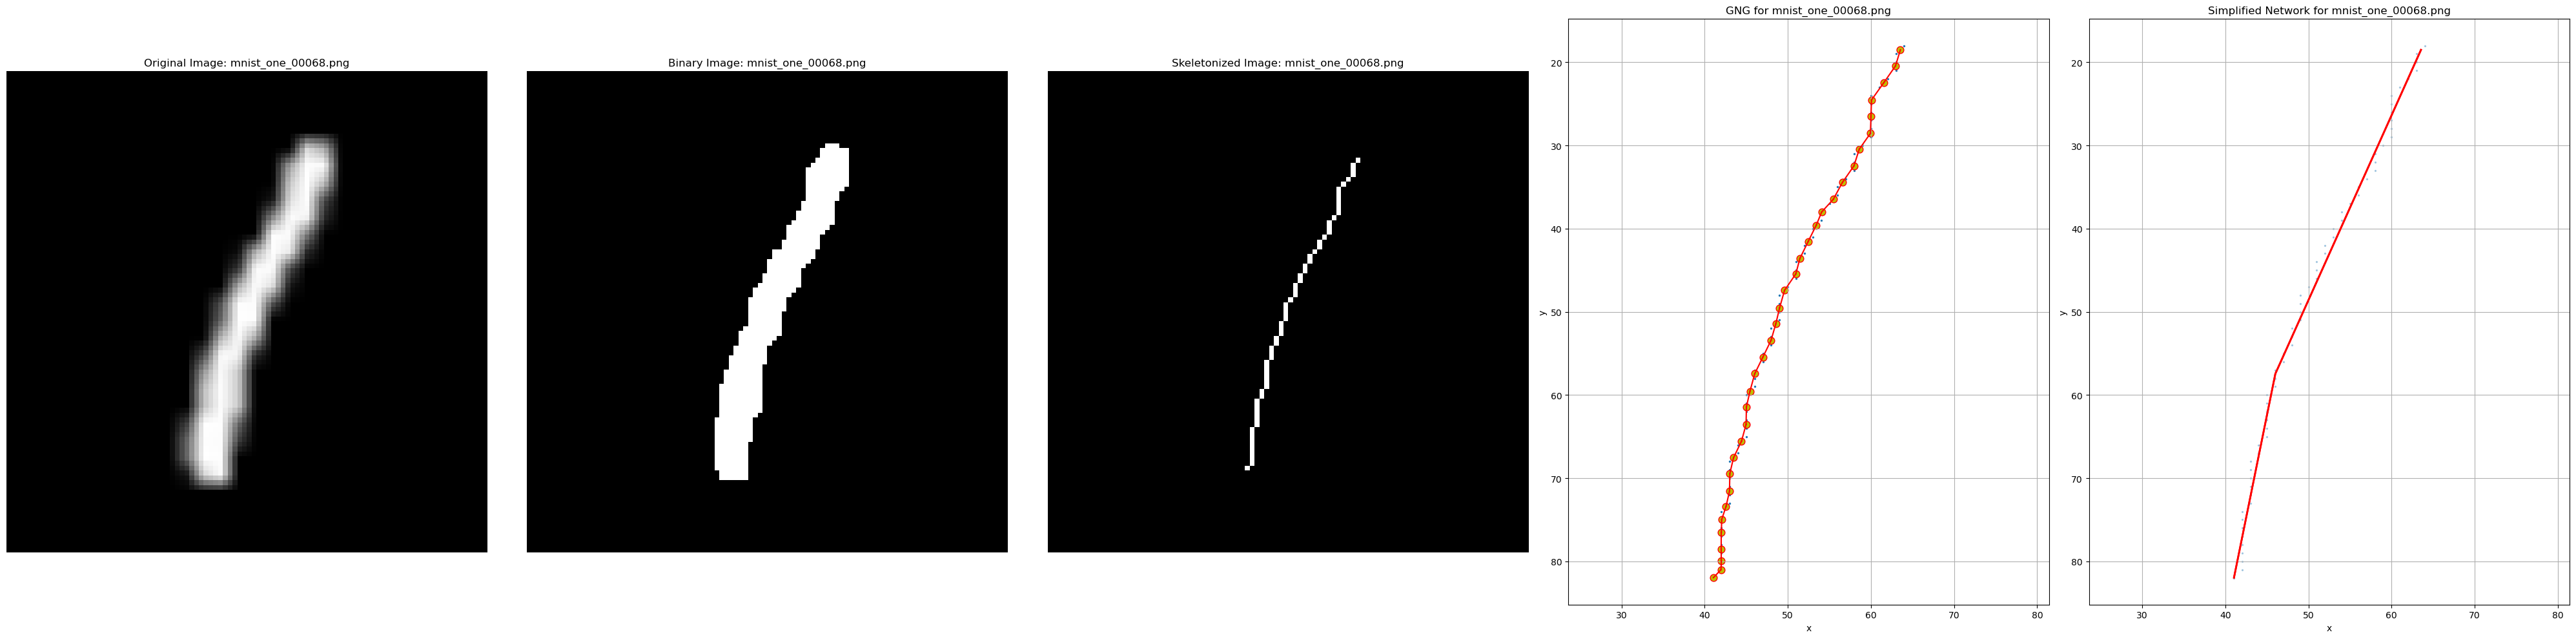

Fitting Growing Neural Gas Network for mnist_one_00054.png...


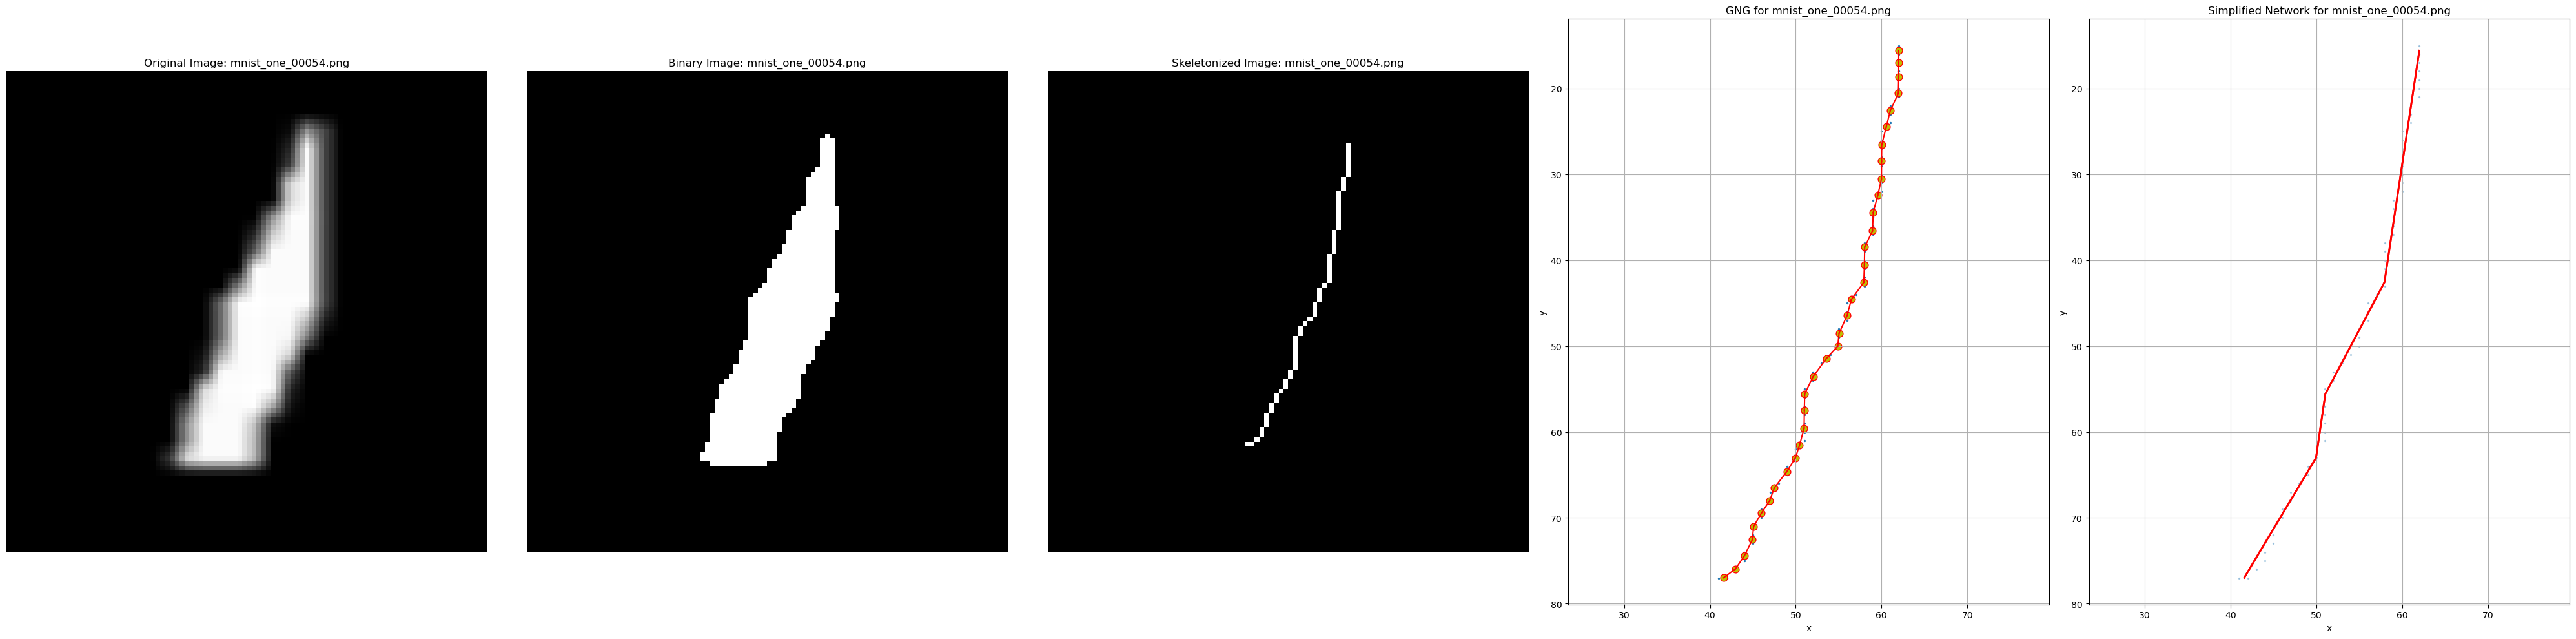

Fitting Growing Neural Gas Network for mnist_one_00040.png...


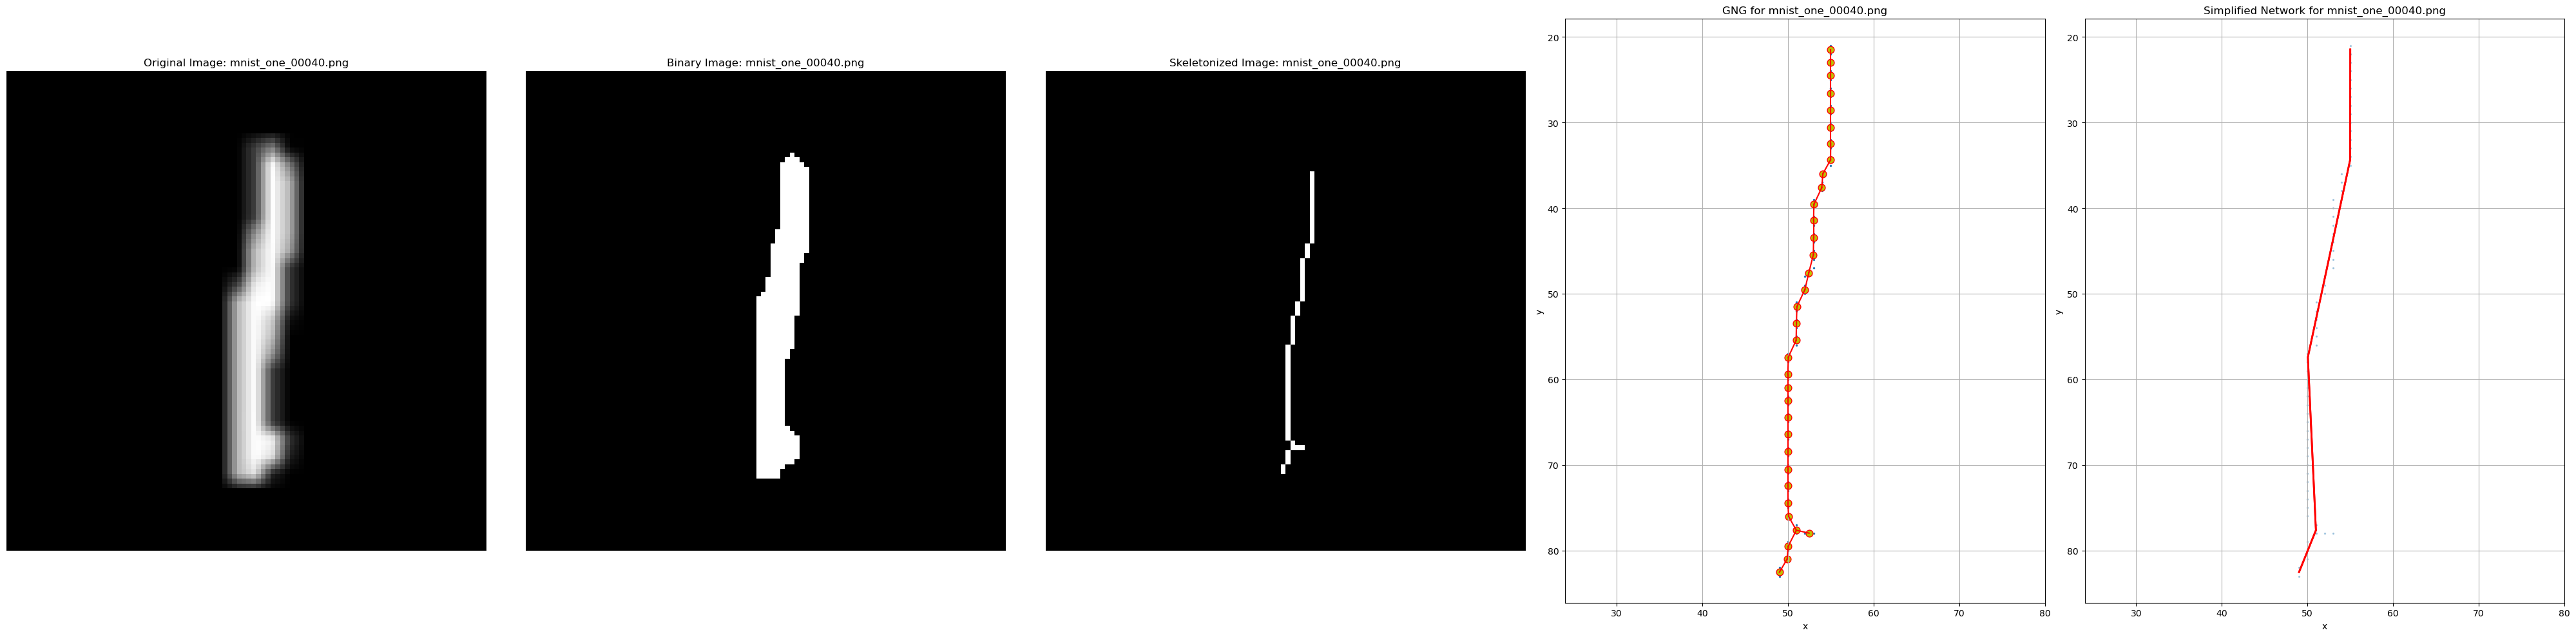

Fitting Growing Neural Gas Network for mnist_one_00041.png...


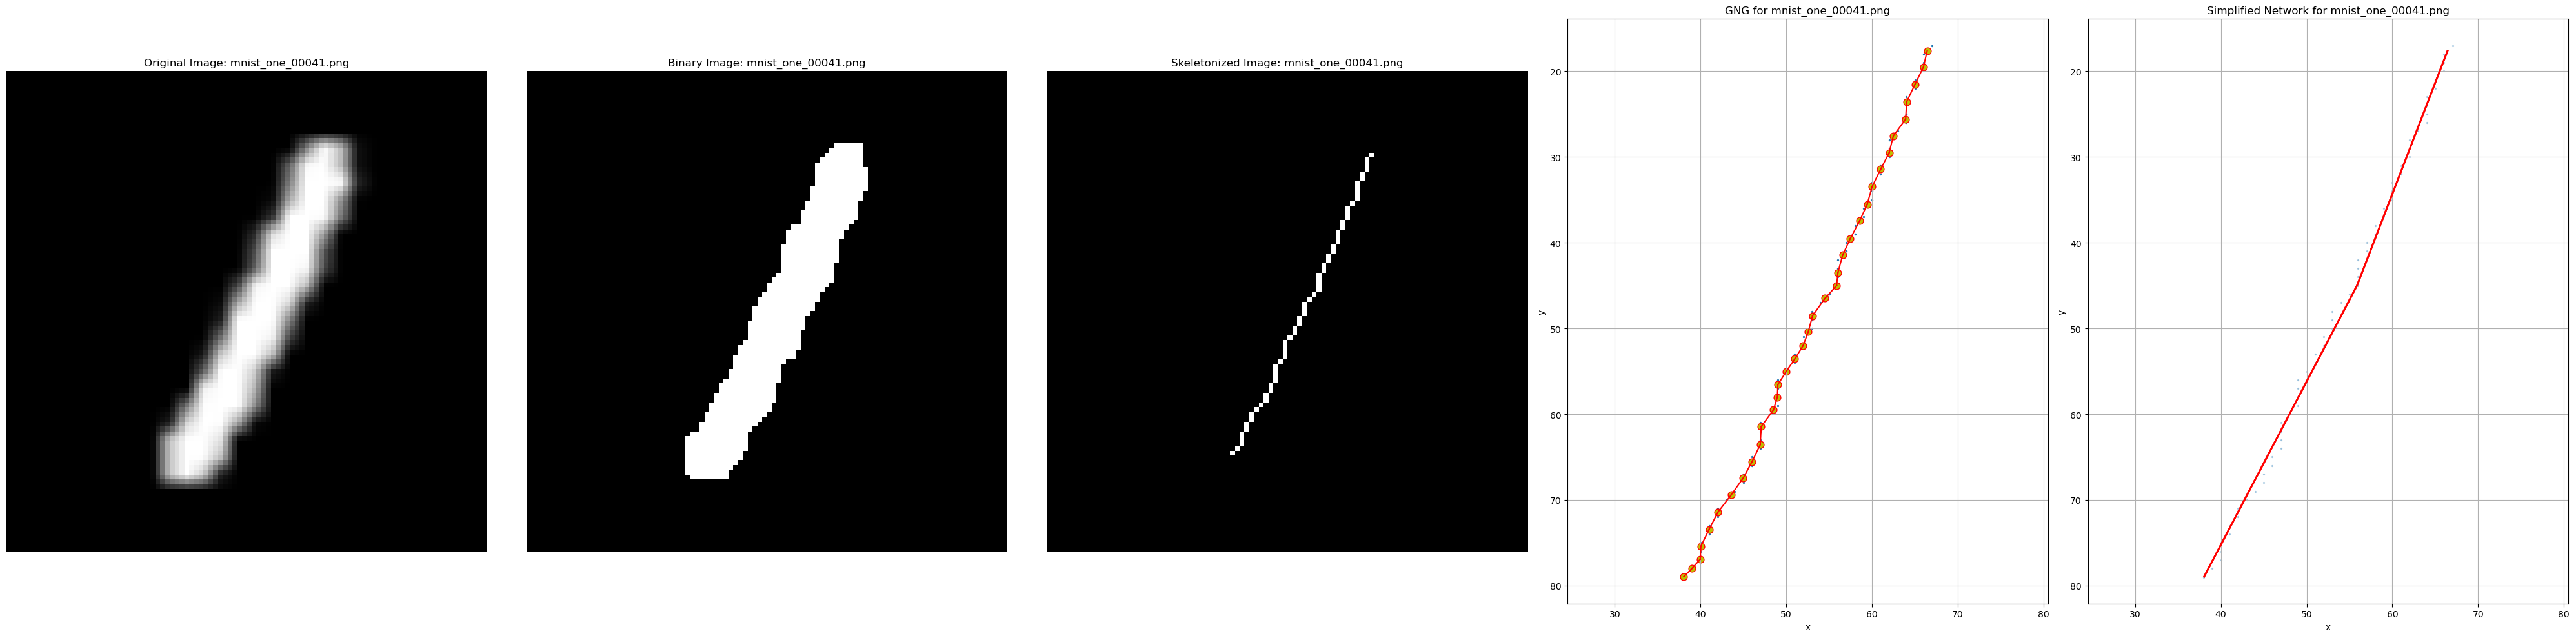

Fitting Growing Neural Gas Network for mnist_one_00055.png...


KeyboardInterrupt: 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ypstruct import structure
import gng
import cv2
import os
from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte
from rdp import rdp

epsilon = 1

# Read all images from the specified folder
folder_path = '../../tests/generated_samples/mnist_ones'  # Replace with the actual folder path
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.gif'))]

def simplify_network(net, epsilon=2.0):
    # Find endpoints and intersections
    degree = np.sum(net.C, axis=0)
    endpoints = set(np.where(degree == 1)[0])
    intersections = set(np.where(degree > 2)[0])
    
    simplified_segments = []
    visited_edges = set()
    
    def traverse_segment(start, current):
        segment = [net.w[start]]
        while current not in endpoints and current not in intersections:
            segment.append(net.w[current])
            neighbors = set(np.where(net.C[current] == 1)[0]) - {start}
            if not neighbors:
                break
            start, current = current, neighbors.pop()
        segment.append(net.w[current])
        return segment, current

    def process_node(node):
        neighbors = set(np.where(net.C[node] == 1)[0])
        for neighbor in neighbors:
            if (node, neighbor) not in visited_edges and (neighbor, node) not in visited_edges:
                visited_edges.add((node, neighbor))
                visited_edges.add((neighbor, node))
                segment, end = traverse_segment(node, neighbor)
                if len(segment) > 2:
                    simplified_segment = rdp(np.array(segment), epsilon)
                    simplified_segments.append(simplified_segment)
                if end != neighbor:
                    process_node(end)

    # Process all endpoints and intersections
    for node in endpoints.union(intersections):
        process_node(node)
    
    return simplified_segments

for image_file in image_files:
    # Read the image
    data = cv2.imread(os.path.join(folder_path, image_file), 0)

    # Skeletonize the image
    binary = data > 150
    skeleton = skeletonize(binary)
    skeleton = img_as_ubyte(skeleton)

    h, w = skeleton.shape

    points = []

    for y in range(h):
        for x in range(w):
            # Threshold the pixel
            if skeleton[y, x] > 0:
                points.append([x, y])

    points_np = np.array(points)


    # Neural Gas Parameters
    params = structure()
    params.N = 35
    params.maxit = 150
    params.L = 100
    params.epsilon_b = 0.2
    params.epsilon_n = 0.01
    params.alpha = 0.5
    params.delta = 0.995
    params.T = 50

    # Fit Neural Gas to Data
    print(f"Fitting Growing Neural Gas Network for {image_file}...")
    net = gng.fit(points_np, params)
    
    # Simplify the network
    simplified_network = simplify_network(net, epsilon=epsilon)

    # Create a figure with four subplots side by side
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(40, 10))

    # Plot original image on the left
    ax1.imshow(data, cmap='gray')
    ax1.set_title(f'Original Image: {image_file}')
    ax1.axis('off')
    
    ax2.imshow(binary, cmap='gray')
    ax2.set_title(f'Binary Image: {image_file}')
    ax2.axis('off')

    # Plot skeletonized image in the middle-left
    ax3.imshow(skeleton, cmap='gray')
    ax3.set_title(f'Skeletonized Image: {image_file}')
    ax3.axis('off')

    # Plot GNG result in the middle-right
    ax4.grid()
    ax4.scatter(points_np[:, 0], points_np[:, 1], s=2)
    for i in range(params.N):
        for j in range(i+1, params.N):
            if net.C[i, j] == 1:
                ax4.plot([net.w[i, 0], net.w[j, 0]], [net.w[i, 1], net.w[j, 1]], c='r')

    ax4.scatter(net.w[:, 0], net.w[:, 1], s=60, c='y', edgecolors='r')

    ax4.set_title(f'GNG for {image_file}')
    ax4.set_xlabel('x')
    ax4.set_ylabel('y')
    ax4.axis('equal')
    ax4.invert_yaxis()  # Invert y-axis to match image coordinates

    # Plot simplified network on the right
    ax5.grid()
    ax5.scatter(points_np[:, 0], points_np[:, 1], s=2, alpha=0.3)
    for segment in simplified_network:
        ax5.plot(segment[:, 0], segment[:, 1], 'r-', linewidth=2)

    ax5.set_title(f'Simplified Network for {image_file}')
    ax5.set_xlabel('x')
    ax5.set_ylabel('y')
    ax5.axis('equal')
    ax5.invert_yaxis()  # Invert y-axis to match image coordinates

    plt.tight_layout()
    plt.show()

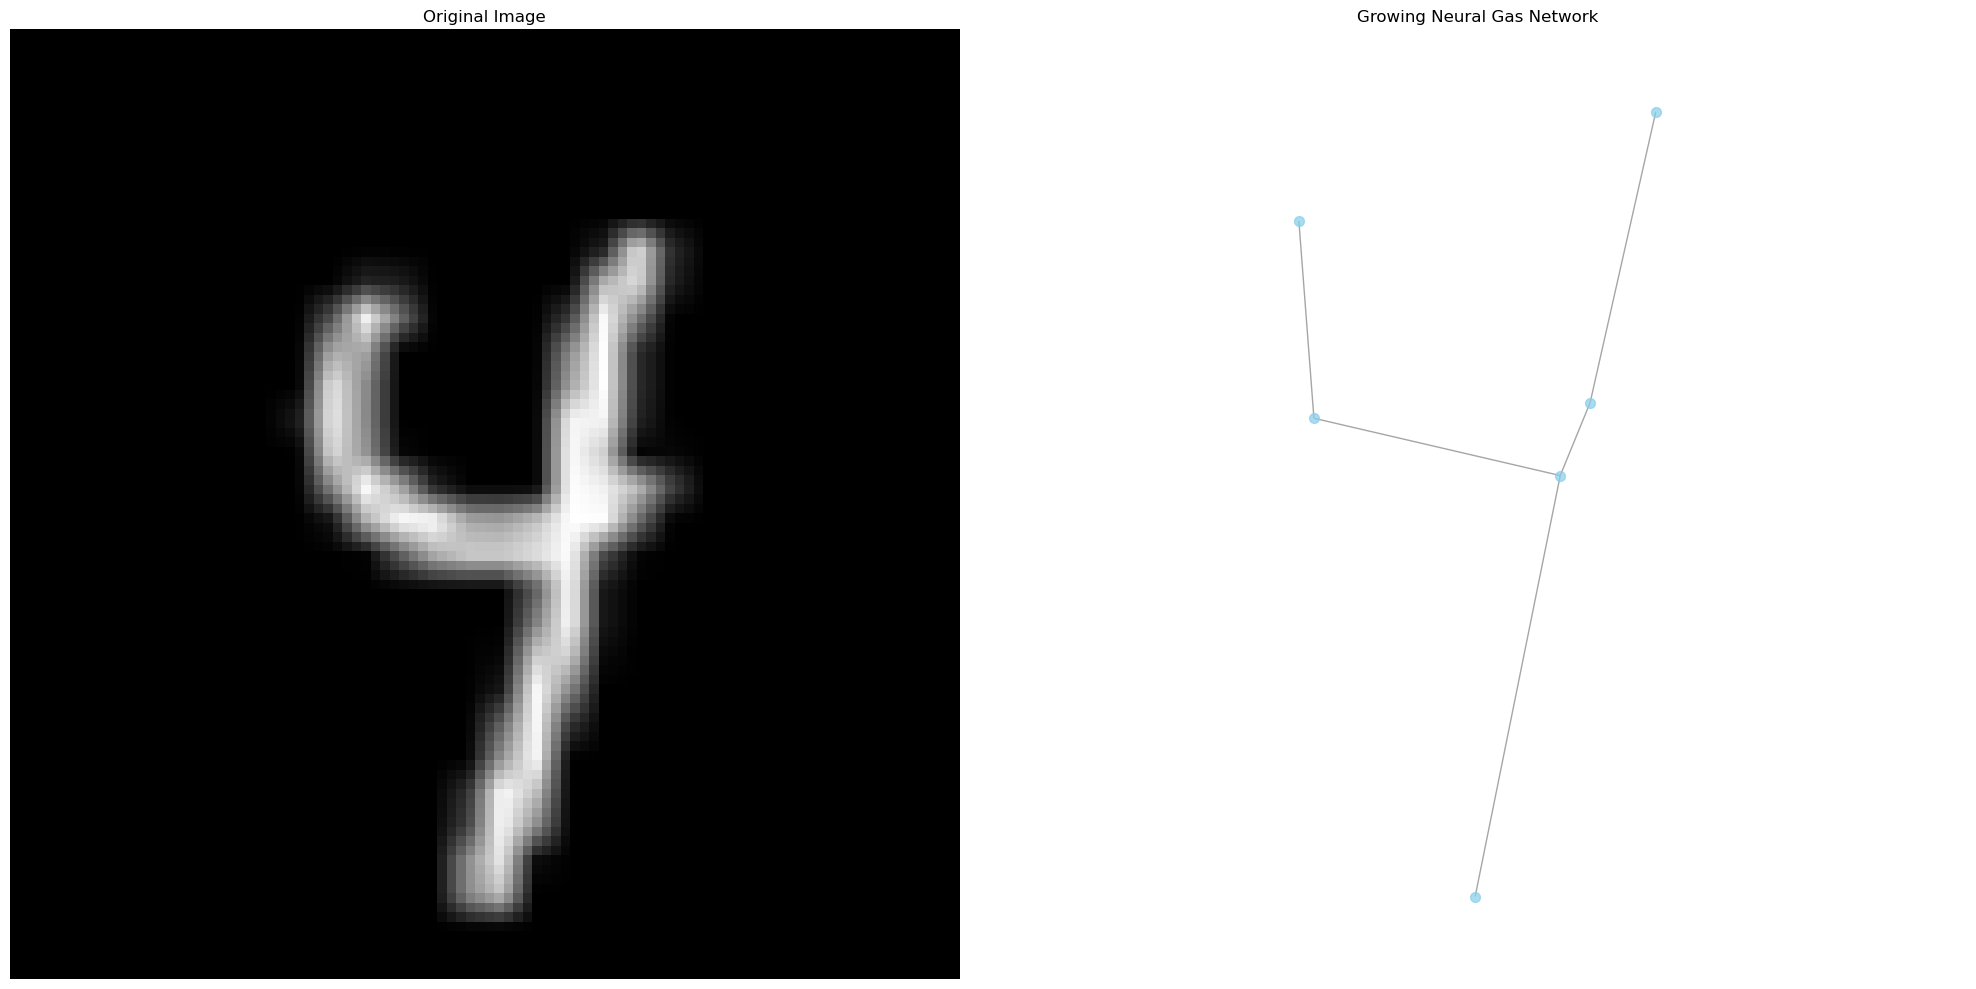

{'directed': False,
 'multigraph': False,
 'graph': {},
 'nodes': [{'x': 60.221750481338276,
   'y': 47.120412555016095,
   'id': 5759549829795195141},
  {'x': 57.76289911456878, 'y': 53.12062140306191, 'id': 5996612825445686960},
  {'x': 37.466873484184674,
   'y': 48.39986614060483,
   'id': -7990009926839235961},
  {'x': 36.2241142313918, 'y': 32.13425914030986, 'id': -2865777355405152915},
  {'x': 65.63737442511754,
   'y': 23.142763546671464,
   'id': -5288813538150289784},
  {'x': 50.7506934085993, 'y': 87.81479122448938, 'id': 2187529656226399937}],
 'links': [{'segment_id': 3,
   'id': 'a410a06f-d36b-4e83-8c8e-2e397849a53d',
   'source': 5759549829795195141,
   'target': 5996612825445686960},
  {'segment_id': 5,
   'id': '274bf870-5bcc-4ff7-b27e-9b89accc0087',
   'source': 5759549829795195141,
   'target': -5288813538150289784},
  {'segment_id': 2,
   'id': '2ddbb4e4-37fa-4fe6-9d75-473911d512b9',
   'source': 5996612825445686960,
   'target': -7990009926839235961},
  {'segment_

In [1]:
from skeleton_gng_mapper import SkeletonGNGMapper
from graph_serializer import GraphSerializer
import networkx as nx
from settings import Settings
import matplotlib.pyplot as plt
import cv2
import json

# path = '../../tests/generated_samples/sk-test/mnist_one_00000.png'
path = '../../tests/generated_samples/sk-test/mnist_four_00003.png'
image = cv2.imread(path, 0)
settings = Settings(
    kafka_topic='skeletonization',
    dlq_topic='skeletonization-dlq',
    kafka_bootstrap_servers='localhost:9092',
    simplification_epsilon=3
)

# Process the image
graph = SkeletonGNGMapper(settings).process_image(image)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the original image
ax1.imshow(image, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

# Create a position dictionary using the node coordinates
pos = {node: (data['x'], data['y']) for node, data in graph.nodes(data=True)}

# Plot the graph
nx.draw(graph, pos, ax=ax2, with_labels=False, node_size=50, node_color='skyblue', edge_color='gray', alpha=0.7)

ax2.set_title('Growing Neural Gas Network')
ax2.axis('equal')  # Set equal aspect ratio
ax2.invert_yaxis()  # Invert y-axis to match image coordinates

plt.tight_layout()
plt.show()

json.loads(json.dumps(GraphSerializer.serialize(graph)))